## A notebook to analyze groups of croparrays  

### Read in, combine, and making measurements 

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Files & Directories
DATA_DIR_1 = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\WT_U2OS\norm_KDM5B\HT\CropArrays")
DATA_DIR_2 = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\dZNF\Norm_KD\HT\CropArrays")
DATA_DIR_3 = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\WT_U2OS\SA\HT\CropArrays")
DATA_DIR_4 = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\dZNF\SA\HT\CropArrays")
OUTPUT = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF")

nc_files_1 = sorted(DATA_DIR_1.glob("*.nc"))
nc_files_2 = sorted(DATA_DIR_2.glob("*.nc"))
nc_files_3 = sorted(DATA_DIR_3.glob("*.nc"))
nc_files_4 = sorted(DATA_DIR_4.glob("*.nc"))

# Nested grouping: outer list = rna, inner list = znf
# GROUPS[rna][znf] -> list of .nc files for that condition
GROUPS = [
    [nc_files_1, nc_files_2],  # KDM5B:         +ZNF598, -ZNF598
    [nc_files_3, nc_files_4],  # KDM5B-XBP1SA:  +ZNF598, -ZNF598
]
DIMS = ["rna", "exp", "fov"]  # dims added during concatenation (outermost to innermost)
LABELS = [["KDM5B", "KDM5B-XBP1SA"], ["+ZNF598", "-ZNF598"], None]  # None = auto-label fovs by filename #

# Measurement parameters
REF_CH = 1  # Channel used to pick best z plane (only used when z was not tracked)
DISK_R = 7  # Radius of signal disk in pixels
DISK_BG = 9 # Radius of background ring in pixels (1 px thick)
ROLL_N = 1  # Rolling z-average window for signal measurement


In [3]:
my_ca = ca.build.open_measure_concat(
    groups=GROUPS,
    dims=DIMS,
    labels=LABELS,
    measure_kwargs=dict(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N,
        drop_int=True, # drop full z-stack to save memory, keeping best_z_proj
    ),
    open_as = "croparray",  # can be croparray or trackarray 
    join="outer",
)

In [4]:
# Create binary masks from "best_z" so can measure morphological properties. 
my_ca.ops.apply(
    ca.tools.binarize_crop_manual,
    channels=[1],               # Channel used to generate mask
    source="best_z",            # Image layer to threshold (typically z-projected signal)
    out_name="ch{ch}_mask",     # Output mask variable name (→ "ch0_mask")

    # Recommended parameters forwarded directly to binarize_crop_manual(...)
    func_kwargs=dict(
        q=0.45,                 # Threshold at 45% after intensity normalization
        q_range=(0.02, 0.999),  # Normalize intensities using 2%–99.9% quantile range
        q_positive_only=True,   # Ignore negative pixels (important for best_z)
        close_px=1,             # Morphological closing (bridge small gaps)
        smooth_px=0,            # Light smoothing of mask edges
        fill_holes=False,       # Do not fill internal holes
        return_uint8=True,      # Store mask as uint8 (0/1)
        morph_px=0,             # Apply a dilation of final mask (morph_pix > 0; <0 for erosion)
    ),
);

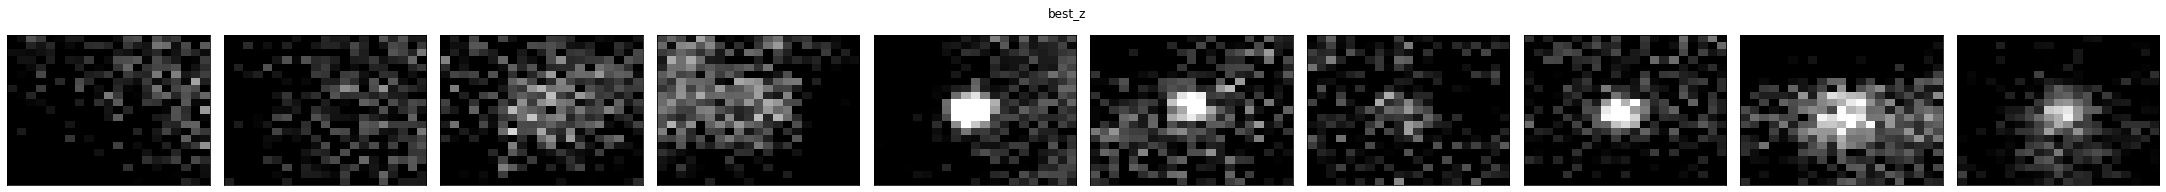

In [5]:
my_ca.isel(exp=0,rna=0,fov=0,ch=1).plot.plot_croparray_crops(n=(0,10,1), layer='best_z',t=(0,1,1), col='n');

In [6]:
# Check masks with napari
viewer, layers = my_ca.napari.montage_viewer(
    row="n",
    col="t",
    ch=1,
    show=("best_z", "ch1_mask"),
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch1_mask": "magenta","best_z": "green"},
    image_contrast=[0.5,99.5],
    show_tile_text=False,
)

In [6]:
# Make measurements of desired properties 
# See https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops
my_ca.measure.mask_props(source ="ch1_mask", props=['eccentricity','major_axis_length_px','minor_axis_length_px']);

In [7]:
# =======================================
# SAVE YOUR WORK TO A NEW CROP/TRACKARRAY
# =======================================

my_file = ca.io.save_croparray(my_ca, output_dir=OUTPUT, ext='.nc')
my_file

C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable xc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
c:\Users\StasLab\anaconda3\envs\croparray_env\lib\site-packages\xarray\core\duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable yc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable zc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable xc_pad with floating poi

WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260409_deltaZNF/Cell01__24rna_exp_fov.nc')

In [8]:
# check your saved data; note concatenation history is saved
temp = ca.tools.open_croparray(my_file)
temp.ds

<xarray.Dataset> Size: 3GB
Dimensions:                         (rna: 2, exp: 2, fov: 6, n: 404, t: 45,
                                     ch: 2, y: 21, x: 21, z: 13)
Coordinates:
  * t                               (t) int32 180B 0 1 2 3 4 ... 40 41 42 43 44
  * n                               (n) int16 808B 0 1 2 3 4 ... 400 401 402 403
  * y                               (y) float64 168B -1.3 -1.17 ... 1.17 1.3
  * x                               (x) float64 168B -1.3 -1.17 ... 1.17 1.3
  * z                               (z) float64 104B 0.0 0.5 1.0 ... 5.0 5.5 6.0
  * ch                              (ch) int32 8B 0 1
  * fov                             (fov) int64 48B 0 1 2 3 4 5
  * exp                             (exp) <U7 56B '+ZNF598' '-ZNF598'
  * rna                             (rna) <U12 96B 'KDM5B' 'KDM5B-XBP1SA'
Data variables: (12/25)
    xc                              (rna, exp, fov, n, t, ch) float32 3MB ...
    yc                              (rna, exp, fov, n, t, ch) float32 3MB ...
    zc                              (rna, exp, fov, n, t, ch) float32 3MB ...
    xc_pix                          (rna, exp, fov, n, t, ch) int16 2MB ...
    yc_pix                          (rna, exp, fov, n, t, ch) int16 2MB ...
    zc_pix                          (rna, exp, fov, n, t, ch) int16 2MB ...
    ...                              ...
    signal                          (rna, exp, fov, n, ch, t) float64 7MB ...
    fov_name                        (rna, exp, fov, n) <U6 233kB ...
    ch1_mask                        (rna, exp, fov, n, t, x, y) uint8 192MB ...
    ch1_mask__eccentricity          (rna, exp, fov, n, t) float64 3MB ...
    ch1_mask__major_axis_length_px  (rna, exp, fov, n, t) float64 3MB ...
    ch1_mask__minor_axis_length_px  (rna, exp, fov, n, t) float64 3MB ...
Attributes: (12/16)
    name:                      Cell01 +23 (concat[24] rna×exp×fov)
    date:                      2026-04-09
    xy_pad:                    10
    z_pad:                     1
    dx:                        0.13
    dy:                        0.13
    ...                        ...
    signal_units:              a.u.
    croparray_schema_version:  2.0
    notes:                     A crop array in WT U2OS cells. Imaged once eve...
    provenance_json:           {\n  "timestamp": "2026-04-13T17:26:29",\n  "d...
    concat_meta_json:          {"base_name": "Cell01", "dims": ["rna", "exp",...
    filename:                  Cell01__24rna_exp_fov.nc

### Manual filtering of saved croparray

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

INPUT_FILE = Path(r'//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260409_deltaZNF/Cell01__24rna_exp_fov.nc')

In [3]:
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import CropArray
my_ca: CropArray = ca.io.open_croparray(INPUT_FILE, as_object=True)

In [5]:
# Automatically flag bad crops based on mask quality. Crops are marked bad (1) if their
# mask area is more than 2x the median (area_factor=2.0) or if the mask centroid is more
# than 4 pixels from the crop center (max_dist_px=4). This catches dim spots where the
# mask is essentially noise. Saves a sidecar .nc file so the filter persists with the data.
filter_name = "bad"
my_ca.measure.auto_bad(
    source='ch1_mask',
    area_factor=2.0,
    max_dist_px=4,
    exclude_empty=False,
    out_name='auto_bad',
    save_sidecar=True,
    output_dir=INPUT_FILE.parent,
);

[auto_bad] Saved sidecar: \\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Cell01__24rna_exp_fov__manual__auto_bad.nc


In [ ]:
# Quick and user-friendly check and manual filtering of 'bad' tracks with napari 
# Can also create other manual filters like 'toi' to highlight tracks of interest  
filter_name = "bad"
viewer, layers, ft = my_ca.napari.manual_filter_montage(
    row="n",  # can be 'track_id' for trackarrays or 'n' for croparrays               
    col="t",  
    filter_name=filter_name,
    show=("best_z", "ch1_mask"),
    ch=1,
    colormaps={"ch1_mask":"magenta", "best_z":"green", filter_name:"yellow"},
    output_dir= INPUT_FILE.parent,
    show_tile_text=False, # adds layer w/ crop coords; takes memory,
    show_click_info=True, # useful for debugging
)

INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell0

In [40]:
# # Test your filter:
my_ca.where(my_ca.ds[filter_name] == 0).napari.montage_viewer(row="n", col="t",show=("best_z","ch1_mask"),ch=1,show_tile_text=False)

(Viewer(camera=Camera(center=(0.0, np.float64(1448.5), np.float64(472.0)), zoom=np.float64(0.26224982746721875), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(1.0), np.float64(2.0), 0.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=4, ndisplay=2, order=(0, 1, 2, 3), axis_labels=('exp', 'fov', 'y', 'x'), rollable=(True, True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(2.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(4.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(2897.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(944.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0, 0.0), 